In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
import joblib

In [12]:
df=pd.read_csv("housing.csv")


In [13]:
print(df.head())


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [14]:
print("Shape:",df.shape)

Shape: (20640, 10)


In [15]:
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [17]:
print(df.describe(include="all"))

           longitude      latitude  housing_median_age   total_rooms  \
count   20640.000000  20640.000000        20640.000000  20640.000000   
unique           NaN           NaN                 NaN           NaN   
top              NaN           NaN                 NaN           NaN   
freq             NaN           NaN                 NaN           NaN   
mean     -119.569704     35.631861           28.639486   2635.763081   
std         2.003532      2.135952           12.585558   2181.615252   
min      -124.350000     32.540000            1.000000      2.000000   
25%      -121.800000     33.930000           18.000000   1447.750000   
50%      -118.490000     34.260000           29.000000   2127.000000   
75%      -118.010000     37.710000           37.000000   3148.000000   
max      -114.310000     41.950000           52.000000  39320.000000   

        total_bedrooms    population    households  median_income  \
count     20433.000000  20640.000000  20640.000000   20640.000000 

In [18]:
print(df.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [19]:
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

C:\Users\SaiVamshiGudem\AppData\Local\Temp\ipykernel_6176\2164095440.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


0         129.0
1        1106.0
2         190.0
3         235.0
4         280.0
          ...  
20635     374.0
20636     150.0
20637     485.0
20638     409.0
20639     616.0
Name: total_bedrooms, Length: 20640, dtype: float64

In [20]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


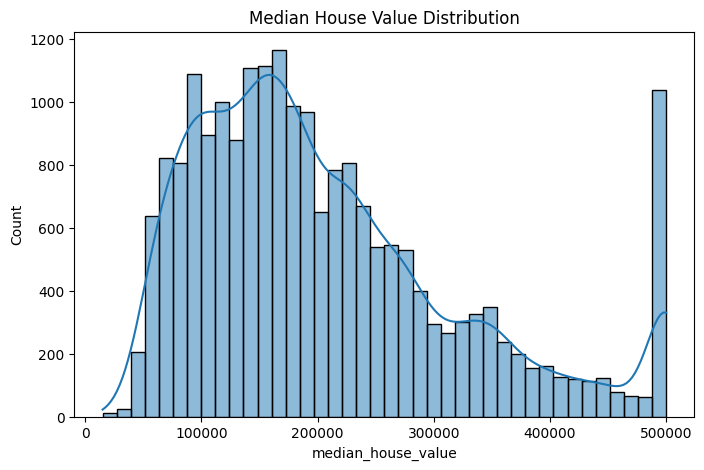

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"],bins=40,kde=True)
plt.title("Median House Value Distribution")
plt.show()


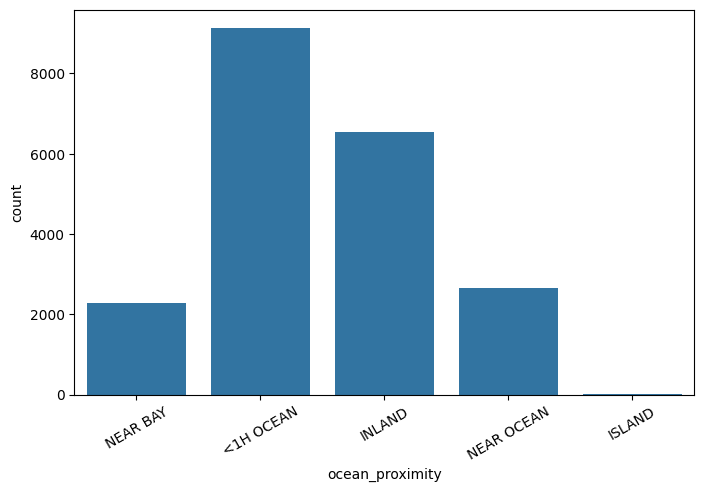

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="ocean_proximity")
plt.xticks(rotation=30)
plt.show()

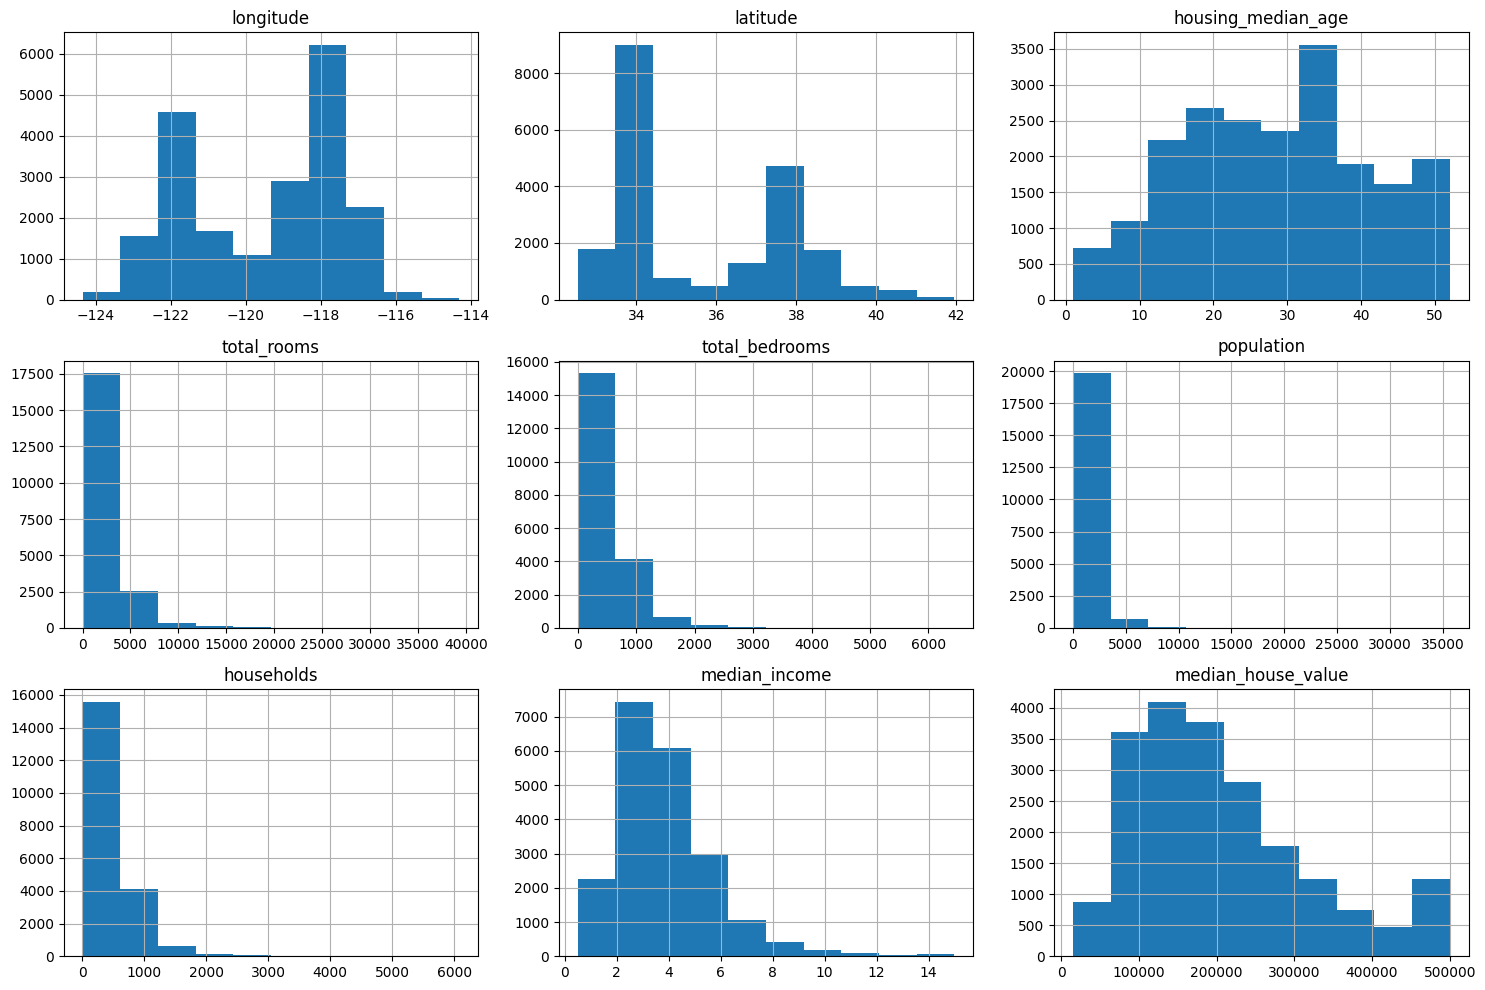

In [23]:
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

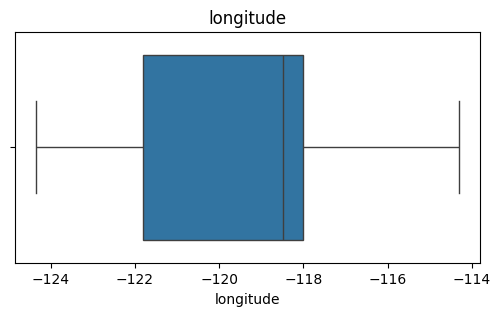

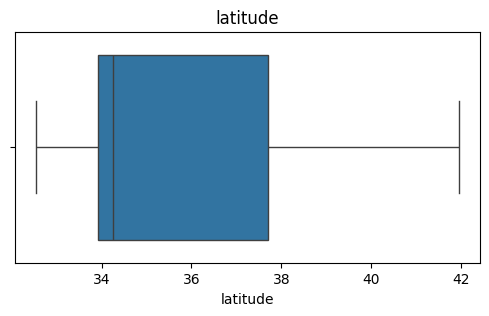

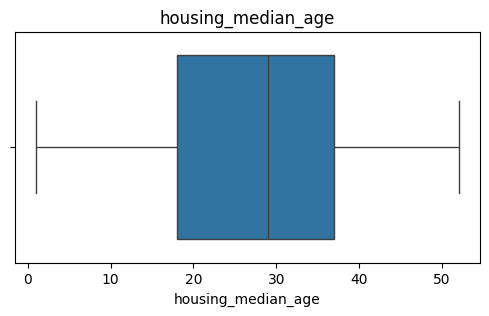

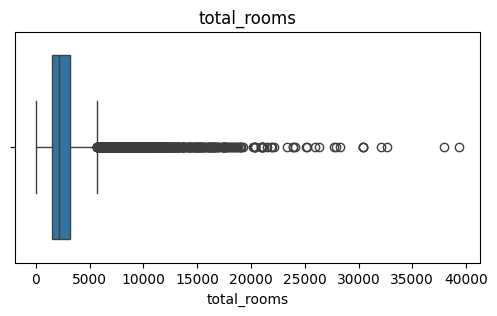

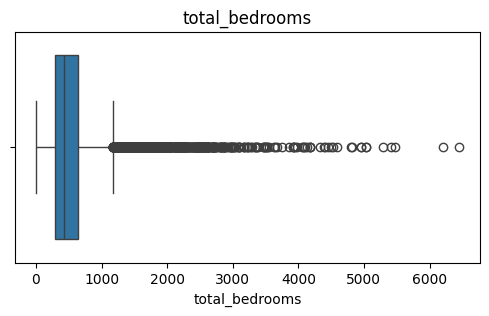

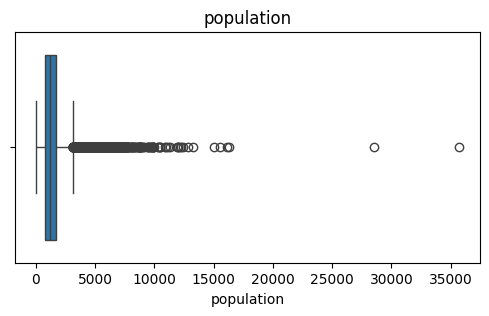

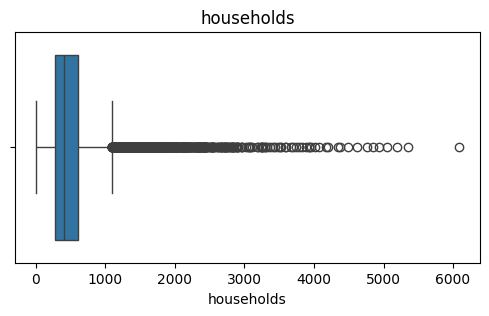

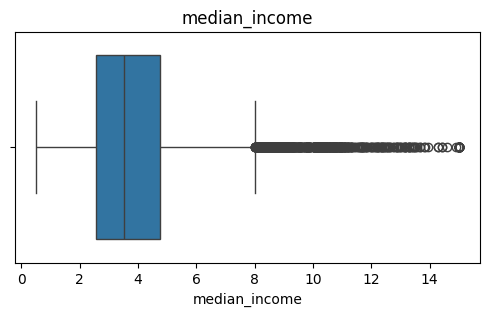

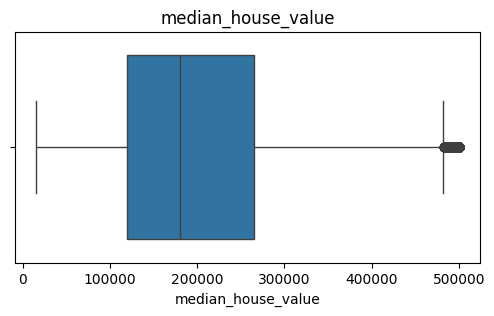

In [24]:
num_cols=df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [25]:
encoder=LabelEncoder()
df["ocean_proximity"]=encoder.fit_transform(df["ocean_proximity"])


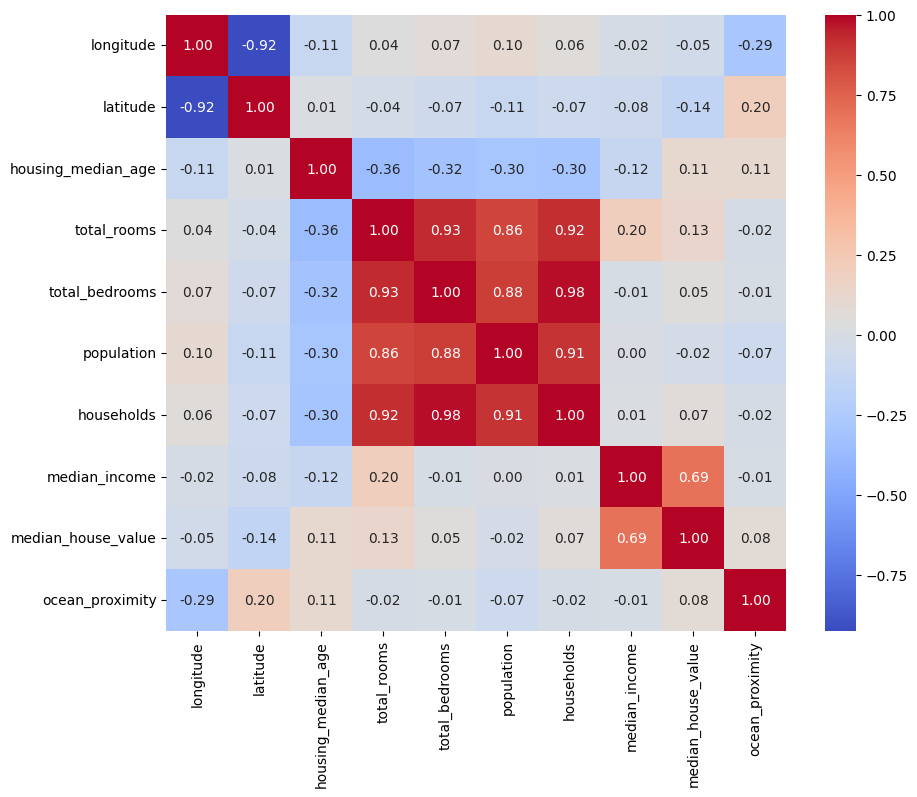

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [27]:
X=df.drop("median_house_value",axis=1)
y=df["median_house_value"]

In [28]:
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

In [29]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [30]:
print("Training:",X_train.shape)
print("Testing :",X_test.shape)
print("Target Train:",y_train.shape)
print("Target Test :",y_test.shape)

print("Columns Used:")
print(['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity'])

Training: (16512, 9)
Testing : (4128, 9)
Target Train: (16512,)
Target Test : (4128,)
Columns Used:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler

In [32]:
a=tf.constant([[1,2],[3,4]])
b=tf.constant([[5,6],[7,8]])
print(a)
print(b)


tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[5 6]
 [7 8]], shape=(2, 2), dtype=int32)


In [33]:
v=tf.Variable([[10.,20.],[30.,40.]])
print(v)


<tf.Variable 'Variable:0' shape=(2, 2) dtype=float32, numpy=
array([[10., 20.],
       [30., 40.]], dtype=float32)>


In [34]:
print(tf.add(a,b))
print(tf.subtract(a,b))
print(tf.multiply(a,b))
print(tf.matmul(a,b))


tf.Tensor(
[[ 6  8]
 [10 12]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[-4 -4]
 [-4 -4]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[ 5 12]
 [21 32]], shape=(2, 2), dtype=int32)
tf.Tensor(
[[19 22]
 [43 50]], shape=(2, 2), dtype=int32)


In [35]:
print(tf.reshape(a,(4,)))

tf.Tensor([1 2 3 4], shape=(4,), dtype=int32)


In [36]:
x=tf.Variable(5.0)
with tf.GradientTape() as tape:
    y_grad=x**2+3*x+2
grad=tape.gradient(y_grad,x)
print("Gradient:",grad.numpy())


Gradient: 13.0


In [37]:
model=Sequential([
Dense(64,activation="relu",input_shape=(X_train.shape[1],)),
Dropout(0.2),
Dense(32,activation="relu"),
Dense(16,activation="relu"),
Dense(1)
])

C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(optimizer="adam",loss="mse",metrics=["mae"])

In [39]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
early=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

In [41]:
history=model.fit(
X_train,y_train,
validation_split=0.2,
epochs=50,
batch_size=32,
callbacks=[early],
verbose=1)


Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 54672928768.0000 - mae: 203673.8438 - val_loss: 49047257088.0000 - val_mae: 190016.3281
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 28794341376.0000 - mae: 133209.0312 - val_loss: 13698972672.0000 - val_mae: 84908.9531
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 11306295296.0000 - mae: 77790.1953 - val_loss: 9836101632.0000 - val_mae: 71459.3281
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 9088065536.0000 - mae: 69175.0156 - val_loss: 8282067456.0000 - val_mae: 65242.0039
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7856181760.0000 - mae: 64000.5039 - val_loss: 7285427200.0000 - val_mae: 61308.9297
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 7091338752.0000 - mae: 60482.9844 - val_loss: 6523136512.0000 - val_mae: 58085.9453
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 6445224448.0000 - mae: 57836.2891 - val_loss: 5976926208.0000 - val_

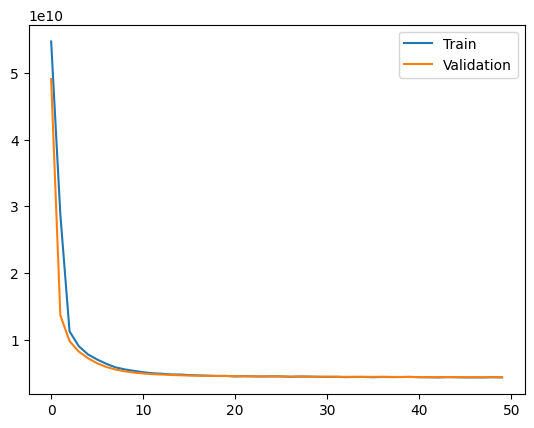

In [42]:
plt.plot(history.history["loss"],label="Train")
plt.plot(history.history["val_loss"],label="Validation")
plt.legend()
plt.show()

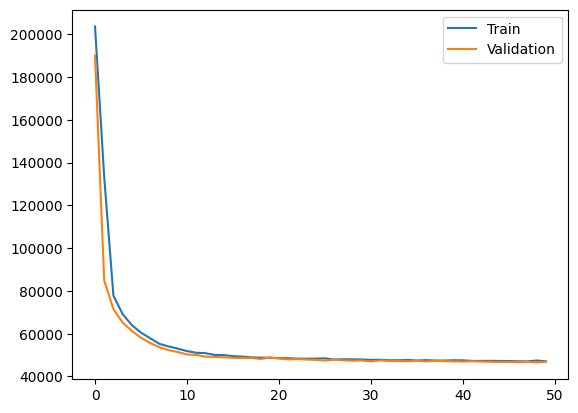

In [43]:
plt.plot(history.history["mae"],label="Train")
plt.plot(history.history["val_mae"],label="Validation")
plt.legend()
plt.show()

In [44]:
pred=model.predict(X_test)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 732us/step


In [45]:
mae=mean_absolute_error(y_test,pred)
mse=mean_squared_error(y_test,pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 54497.718048568844
MSE: 6823064790.450503
RMSE: 82601.8449579094
R2: 0.4793179149604253


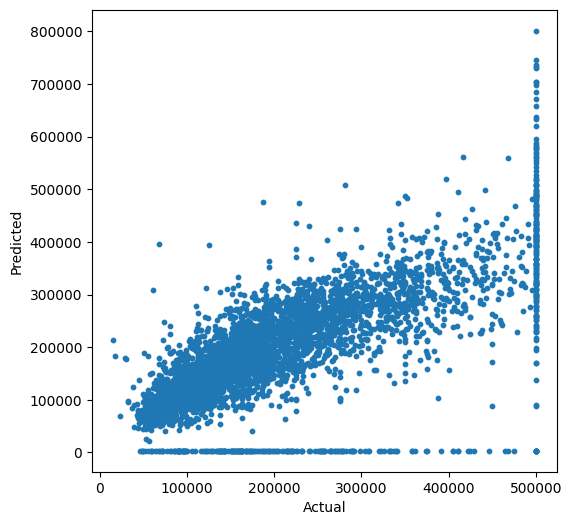

In [46]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,pred,s=10)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


In [47]:
model.save("housing_price_tf.keras")
print("Model Saved")

Model Saved


In [48]:
loaded=tf.keras.models.load_model("housing_price_tf.keras")
print(loaded.predict(X_test[:2]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[3095.553]
 [3095.553]]


In [49]:
from fastapi import FastAPI
from pydantic import BaseModel
import tensorflow as tf
import joblib
import numpy as np

In [50]:
model=tf.keras.models.load_model("housing_price_tf.keras")
scaler=joblib.load("scaler.pkl")

In [51]:
app=FastAPI(
    title="California Housing Price Prediction API",
    version="1.0",
    description="TensorFlow Regression API"
)

In [52]:
class HouseInput(BaseModel):
    longitude: float
    latitude: float
    housing_median_age: float
    total_rooms: float
    total_bedrooms: float
    population: float
    households: float
    median_income: float
    ocean_proximity: int


In [53]:
@app.get("/")
def home():
    return {"message":"Housing Price Prediction API is running"}

In [54]:
@app.post("/predict")
def predict(data:HouseInput):
    features=np.array([[
        data.longitude,
        data.latitude,
        data.housing_median_age,
        data.total_rooms,
        data.total_bedrooms,
        data.population,
        data.households,
        data.median_income,
        data.ocean_proximity
    ]])
    features=scaler.transform(features)
    pred=model.predict(features,verbose=0)
    return {"predicted_house_value":round(float(pred[0][0]),2)}
